In [5]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

In [6]:
# Set layer widths

widthS = 10
widthF = 1
widthP = 30

# Set up lattice
X, Y = widthS+widthF+widthP, 200
lattice = Lattice(X, Y)

# Set up Hamiltonian parameters
t = 1
T = 0.003

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t

mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

hz0 = 0.9 * t
hz = np.zeros_like(mu)
hz[widthS:widthS + widthF] = hz0

# U, V and V' must be of dimensions (lattice.X,) or None
U0 = 4 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V0 = 2 * t
V = V0 * np.ones(lattice.X)
V[:widthF+widthS] = 0
V[widthF+widthS-1] = V0/2

V_prime = None

In [7]:
# Set up Hamiltonian with 
# initial guesses for the order parameters

H = Hamiltonian(
    t, mu, lattice,
    U=U, V_prime=V_prime, V=V,
    F0_init=0.1,
    F_init=[0.1, -0.1, 0.1j, -0.1j],
    hz=hz)

In [8]:
# Perform self-consistency iterations

bdg_sc( H, maxiter=1000, temperature=T, rtol=0.001, atol=1e-6)
F, Fuu, Fdd = H.get_correlations()

Converged after 115 iterations


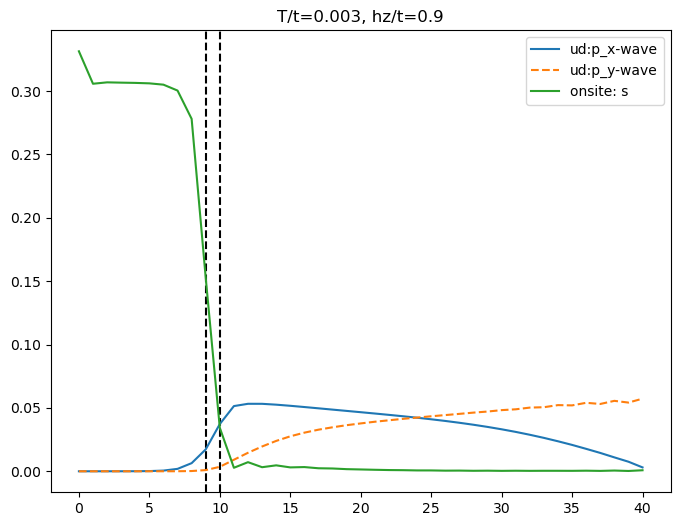

In [9]:
x = np.arange(0, widthS + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hz/t={hz0}")
axs.axvline(int(widthS)-1, color='black', linestyle='--')
axs.axvline(widthS+widthF-1, color='black', linestyle='--')

axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(H.F0), label="onsite: s")
axs.legend()
plt.show()

In [10]:
from scripts.utils import is_hermitian

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))

True
True
True
